In [13]:
import globals
import numpy as np
import nibabel as nb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import PcmPy as pcm
import warnings
import globals as gl
import rsatoolbox as rsa
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

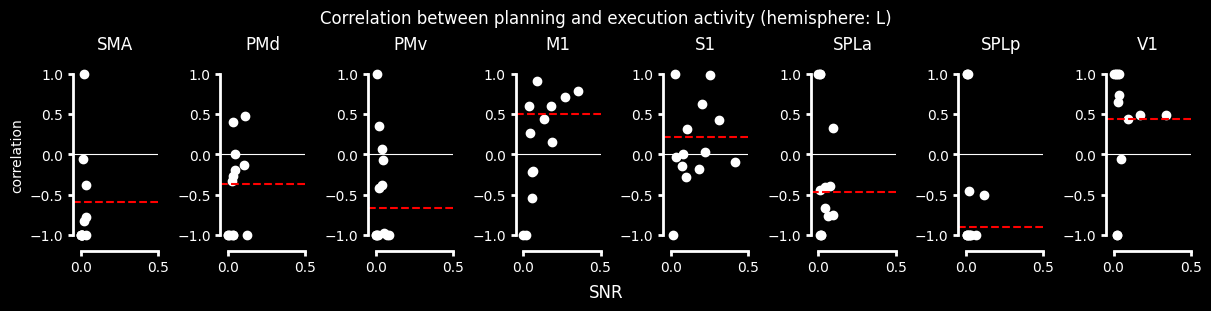

In [57]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
N = 13

Mflex = pcm.CorrelationModel("flex", num_items=1, corr=None, cond_effect=False)

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):

    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.pkl'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.pkl'), 'rb')
    theta = pickle.load(f)

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.pkl'), 'rb')
    theta_g = pickle.load(f)

    sigma2_1 = np.exp(theta[0][0])
    sigma2_2 = np.exp(theta[0][1])
    r_indiv = Mflex.get_correlation(theta[0])
    sigma2_e = np.exp(theta[0][3])
    SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
    axs[r].scatter(SNR, r_indiv, color='w')

    theta_g,_= pcm.group_to_individ_param(theta_g[0],Mflex,N)
    r_group = Mflex.get_correlation(theta_g)
    axs[r].axhline(r_group[0], color='w', linestyle='--')
    axs[r].axhline(0, color='w', linestyle='-', lw=.8)
    axs[r].set_title(roi)

    axs[r].set_ylim(-1.2, 1.2)
    axs[r].set_xlim(-.05, .5)

    axs[r].spines[['top', 'right',]].set_visible(False)
    axs[r].spines[['bottom']].set_bounds(0, .5)
    axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].tick_params(width=2)
    axs[r].spines[['left']].set_bounds(-1, 1)
    # axs[r].tick_params(axis='y', width=0)

    if r==0:
        axs[r].spines[['left']].set_visible(True)

        axs[r].spines[['left']].set_linewidth(2)
        axs[r].tick_params(axis='y', width=2)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between planning and execution activity (hemisphere: {H})')

plt.show()


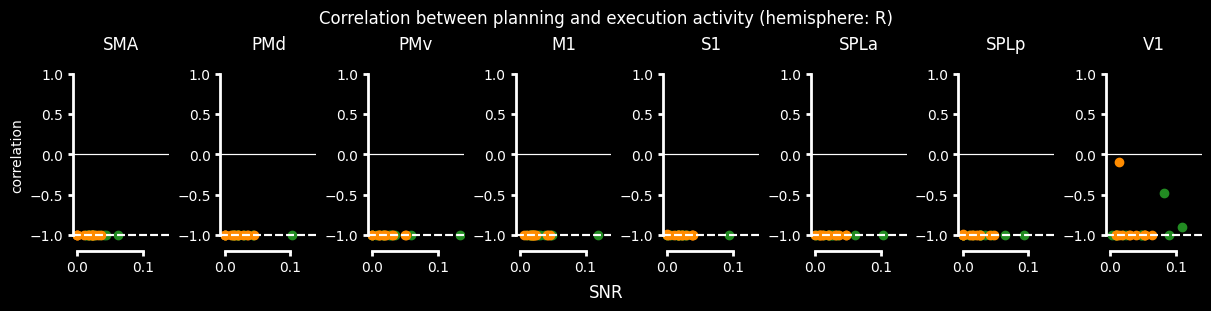

In [62]:
experiment = 'smp2'
glm = 12
H = 'R'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
N = 13

finger = 'index'

Mflex = pcm.CorrelationModel("flex", num_items=1, corr=None, cond_effect=False)

fig, axs = plt.subplots(1, len(rois),  sharex=True, figsize=(12, 3), constrained_layout=True)

for color, finger in zip(['forestgreen', 'darkorange'], ['index', 'ring'], ):
    for r, roi in enumerate(rois):

        T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.{finger}.glm{glm}.{H}.{roi}.pkl'))
        f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.{finger}.glm{glm}.{H}.{roi}.pkl'), 'rb')
        theta = pickle.load(f)

        f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.{finger}.glm{glm}.{H}.{roi}.pkl'), 'rb')
        theta_g = pickle.load(f)

        sigma2_1 = np.exp(theta[0][0])
        sigma2_2 = np.exp(theta[0][1])
        r_indiv = Mflex.get_correlation(theta[0])
        sigma2_e = np.exp(theta[0][3])
        SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
        axs[r].scatter(SNR, r_indiv, color=color)

        theta_g,_= pcm.group_to_individ_param(theta_g[0],Mflex,N)
        r_group = Mflex.get_correlation(theta_g)
        axs[r].axhline(r_group[0], color='w', linestyle='--')
        axs[r].axhline(0, color='w', linestyle='-', lw=.8)
        axs[r].set_title(roi)

        axs[r].set_ylim(-1.2, 1.2)
        # axs[r].set_xlim(-.05, 50)

        axs[r].spines[['top', 'right',]].set_visible(False)
        axs[r].spines[['bottom']].set_bounds(0, .1)
        axs[r].spines[['bottom','left']].set_linewidth(2)
        axs[r].tick_params(width=2)
        # axs[r].tick_params(axis='y', width=0)

        # if r==0:
        # axs[r].spines[['left']].set_visible(True)
        axs[r].spines[['left']].set_bounds(-1, 1)
        # axs[r].spines[['left']].set_linewidth(2)
        # axs[r].tick_params(axis='y', width=2)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between planning and execution activity (hemisphere: {H})')

plt.show()


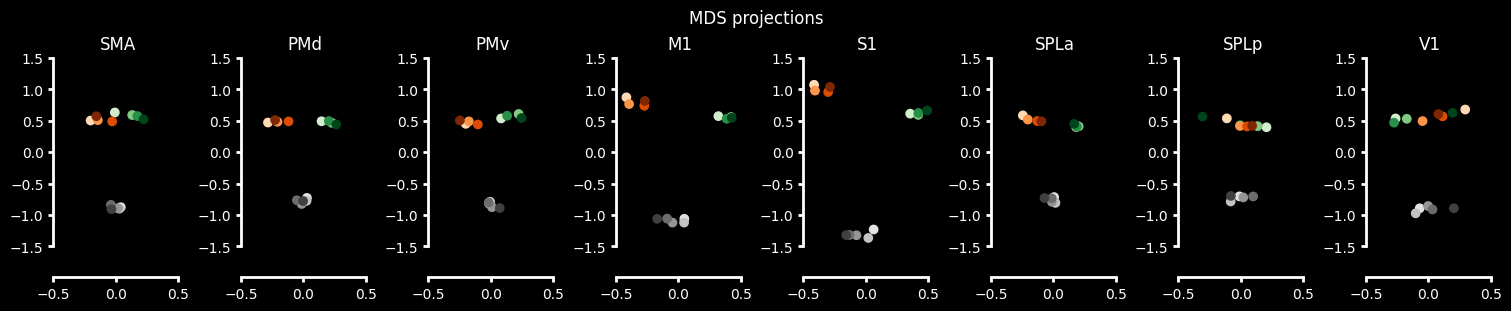

In [46]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

fig, axs = plt.subplots(1, len(rois), figsize=(15, 3), constrained_layout=True)

corry = [-1, -1, -1, 1, -1, -1, -1, -1]
corrx = [-1, -1, 1, -1, 1, -1, 1, 1]

for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan-exec.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    mds, _ = pcm.classical_mds(G)

    axs[r].scatter(mds[:, 1] * corrx[r], mds[:, 0] * corry[r],c=list(gl.colour_mapping.values()))
    axs[r].set_title(roi)
    axs[r].set_ylim(-1.99, 1.5)
    axs[r].set_xlim(-.5, .53)
    axs[r].spines[['top', 'right']].set_visible(False)
    axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].spines[['bottom',]].set_bounds(-.5, .5)
    axs[r].spines[['left',]].set_bounds(-1.5, 1.5)
    axs[r].tick_params(width=2)

fig.suptitle(f'MDS projections')

plt.show()

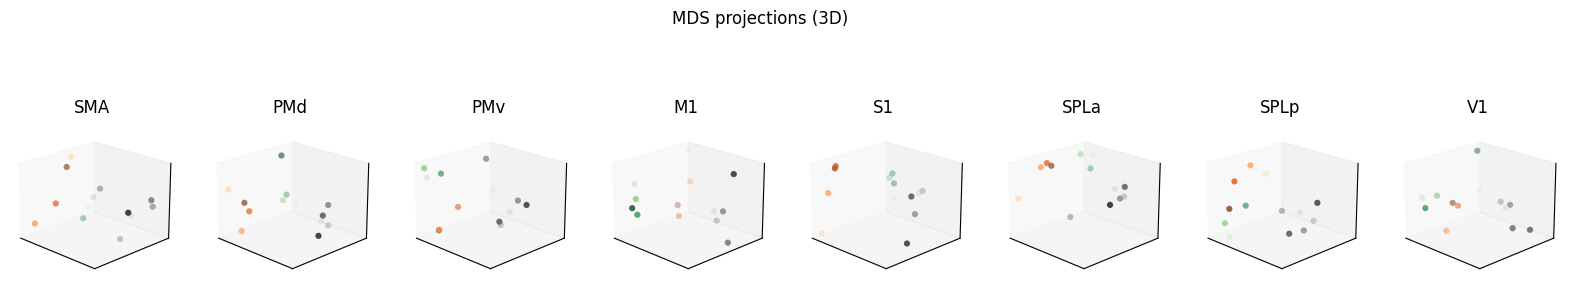

In [53]:
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

fig = plt.figure(figsize=(20, 4))
axs = [fig.add_subplot(1, len(rois), i + 1, projection='3d') for i in range(len(rois))]

for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan-exec.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    mds, _ = pcm.classical_mds(G,)  # Request 3 components

    axs[r].scatter(mds[:, 0], mds[:, 1], mds[:, 2], c=list(gl.colour_mapping.values()), edgecolor='none')
    axs[r].set_title(roi)
    axs[r].set_xticks([])
    axs[r].set_yticks([])
    axs[r].set_zticks([])
    axs[r].view_init(elev=20, azim=-45)

fig.suptitle(f'MDS projections (3D)')
plt.show()